**Predict Learner Course Completion on Moodle-Based Learning Platform**

Build a machine learning model to predict whether a learner will complete a course on a Moodle-based platform using engagement metrics, performance data, course attributes, and geographic constraints. The goal is to identify at-risk learners early and enable targeted interventions to improve course completion rates.

In [ ]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans


In [ ]:
df = pd.read_csv("/content/moodle_course_dataset.csv")

In [ ]:
df

,user_id,age,country,course_type,course_category,course_price,time_spent_hours,assignments_completed,quiz_avg_score,login_frequency_per_week,device_type,last_login_days_ago,forum_posts,video_completion_percent,certificate_attempted,payment_type,course_completed
0,1,32,Canada,Instructor-led Online,Risk,1195,21,6,82,6,Tablet,10,23,99,1,Corporate,0
1,2,19,UK,Classroom Training Live Session,Investment,905,130,11,20,0,Desktop,21,43,88,0,Individual,0
2,3,59,UK,Self-paced,Investment,799,15,13,61,6,Desktop,50,43,54,1,Corporate,0
3,4,54,USA,Classroom Training Live Session,Risk,746,21,8,38,1,Mobile,59,13,8,1,Individual,0
4,5,24,India,Self-paced,Investment,608,8,14,34,5,Mobile,35,49,3,1,Corporate,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,7996,35,India,Self-paced,Investment,1160,90,0,0,2,Mobile,21,18,76,0,Corporate,0
7996,7997,52,UK,Self-paced,Finance,183,26,13,34,4,Desktop,13,28,57,0,Individual,0
7997,7998,35,UK,Instructor-led Online,Risk,947,130,9,97,1,Desktop,28,1,15,1,Corporate,1
7998,7999,53,UK,Instructor-led Online,Accounting,1001,105,4,94,0,Mobile,1,34,27,0,Individual,1


In [ ]:
df.head()


,user_id,age,country,course_type,course_category,course_price,time_spent_hours,assignments_completed,quiz_avg_score,login_frequency_per_week,device_type,last_login_days_ago,forum_posts,video_completion_percent,certificate_attempted,payment_type,course_completed
0,1,32,Canada,Instructor-led Online,Risk,1195,21,6,82,6,Tablet,10,23,99,1,Corporate,0
1,2,19,UK,Classroom Training Live Session,Investment,905,130,11,20,0,Desktop,21,43,88,0,Individual,0
2,3,59,UK,Self-paced,Investment,799,15,13,61,6,Desktop,50,43,54,1,Corporate,0
3,4,54,USA,Classroom Training Live Session,Risk,746,21,8,38,1,Mobile,59,13,8,1,Individual,0
4,5,24,India,Self-paced,Investment,608,8,14,34,5,Mobile,35,49,3,1,Corporate,0


In [ ]:
df.shape

(8000, 17)

In [ ]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   user_id                   8000 non-null   int64 
 1   age                       8000 non-null   int64 
 2   country                   7600 non-null   object
 3   course_type               7600 non-null   object
 4   course_category           7600 non-null   object
 5   course_price              8000 non-null   int64 
 6   time_spent_hours          8000 non-null   int64 
 7   assignments_completed     8000 non-null   int64 
 8   quiz_avg_score            8000 non-null   int64 
 9   login_frequency_per_week  8000 non-null   int64 
 10  device_type               7600 non-null   object
 11  last_login_days_ago       8000 non-null   int64 
 12  forum_posts               8000 non-null   int64 
 13  video_completion_percent  8000 non-null   int64 
 14  certificate_attempted   

In [ ]:
#finding  null values if any
df.isnull().sum()


,0
user_id,0
age,0
country,400
course_type,400
course_category,400
course_price,0
time_spent_hours,0
assignments_completed,0
quiz_avg_score,0
login_frequency_per_week,0


In [ ]:
df = df.dropna(subset=['country','course_type','course_category','device_type','payment_type'])

In [ ]:
df

,user_id,age,country,course_type,course_category,course_price,time_spent_hours,assignments_completed,quiz_avg_score,login_frequency_per_week,device_type,last_login_days_ago,forum_posts,video_completion_percent,certificate_attempted,payment_type,course_completed
0,1,32,Canada,Instructor-led Online,Risk,1195,21,6,82,6,Tablet,10,23,99,1,Corporate,0
1,2,19,UK,Classroom Training Live Session,Investment,905,130,11,20,0,Desktop,21,43,88,0,Individual,0
2,3,59,UK,Self-paced,Investment,799,15,13,61,6,Desktop,50,43,54,1,Corporate,0
3,4,54,USA,Classroom Training Live Session,Risk,746,21,8,38,1,Mobile,59,13,8,1,Individual,0
4,5,24,India,Self-paced,Investment,608,8,14,34,5,Mobile,35,49,3,1,Corporate,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,7996,35,India,Self-paced,Investment,1160,90,0,0,2,Mobile,21,18,76,0,Corporate,0
7996,7997,52,UK,Self-paced,Finance,183,26,13,34,4,Desktop,13,28,57,0,Individual,0
7997,7998,35,UK,Instructor-led Online,Risk,947,130,9,97,1,Desktop,28,1,15,1,Corporate,1
7998,7999,53,UK,Instructor-led Online,Accounting,1001,105,4,94,0,Mobile,1,34,27,0,Individual,1


In [ ]:
df.isnull().sum()


,0
user_id,0
age,0
country,0
course_type,0
course_category,0
course_price,0
time_spent_hours,0
assignments_completed,0
quiz_avg_score,0
login_frequency_per_week,0


Removed 400 null values

In [ ]:
df.duplicated().sum()

np.int64(0)

No duplicates

In [ ]:
df.describe()

,user_id,age,course_price,time_spent_hours,assignments_completed,quiz_avg_score,login_frequency_per_week,last_login_days_ago,forum_posts,video_completion_percent,certificate_attempted,course_completed
count,7600.000000,7600.000000,7600.000000,7600.000000,7600.000000,7600.000000,7600.000000,7600.000000,7600.000000,7600.000000,7600.000000,7600.000000
mean,4007.390263,38.619737,674.849079,90.316184,7.053553,49.633947,3.014868,29.163289,25.919079,49.506184,0.494605,0.356184
std,2307.302127,12.139423,445.743102,59.098945,4.293012,28.908334,1.993453,17.213109,24.369905,28.956738,0.500004,0.478902
min,1.000000,18.000000,100.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2013.750000,28.000000,372.750000,44.000000,3.000000,25.000000,1.000000,14.000000,12.000000,24.000000,0.000000,0.000000
50%,4010.500000,39.000000,658.000000,88.000000,7.000000,49.000000,3.000000,29.000000,24.000000,50.000000,0.000000,0.000000
75%,5998.250000,49.000000,939.000000,133.000000,11.000000,75.000000,5.000000,44.000000,37.000000,75.000000,1.000000,1.000000
max,8000.000000,59.000000,5000.000000,500.000000,14.000000,99.000000,6.000000,59.000000,300.000000,99.000000,1.000000,1.000000


In [ ]:
# Drop user id (unique identifier)
df = df.drop(['user_id'], axis=1)

In [ ]:
df

,age,country,course_type,course_category,course_price,time_spent_hours,assignments_completed,quiz_avg_score,login_frequency_per_week,device_type,last_login_days_ago,forum_posts,video_completion_percent,certificate_attempted,payment_type,course_completed
0,32,Canada,Instructor-led Online,Risk,1195,21,6,82,6,Tablet,10,23,99,1,Corporate,0
1,19,UK,Classroom Training Live Session,Investment,905,130,11,20,0,Desktop,21,43,88,0,Individual,0
2,59,UK,Self-paced,Investment,799,15,13,61,6,Desktop,50,43,54,1,Corporate,0
3,54,USA,Classroom Training Live Session,Risk,746,21,8,38,1,Mobile,59,13,8,1,Individual,0
4,24,India,Self-paced,Investment,608,8,14,34,5,Mobile,35,49,3,1,Corporate,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,35,India,Self-paced,Investment,1160,90,0,0,2,Mobile,21,18,76,0,Corporate,0
7996,52,UK,Self-paced,Finance,183,26,13,34,4,Desktop,13,28,57,0,Individual,0
7997,35,UK,Instructor-led Online,Risk,947,130,9,97,1,Desktop,28,1,15,1,Corporate,1
7998,53,UK,Instructor-led Online,Accounting,1001,105,4,94,0,Mobile,1,34,27,0,Individual,1


Target variable analysis

In [ ]:
df['course_completed'].value_counts()


,count
course_completed,
0,4893
1,2707


In [ ]:
df['course_completed'].value_counts(normalize=True)

,proportion
course_completed,
0,0.643816
1,0.356184


The dataset shows that around 64% of learners complete the course, while 36% do not. This indicates a moderate class imbalance and highlights the need to identify at-risk learners to improve course completion rates.

In [ ]:
#num cols
num_cols = df.select_dtypes(exclude='object').columns
#cat cols
cat_cols = df.select_dtypes(include = "object").columns

In [ ]:
num_cols

Index(['age', 'course_price', 'time_spent_hours', 'assignments_completed',
       'quiz_avg_score', 'login_frequency_per_week', 'last_login_days_ago',
       'forum_posts', 'video_completion_percent', 'certificate_attempted',
       'course_completed'],
      dtype='object')

In [ ]:
cat_cols

Index(['country', 'course_type', 'course_category', 'device_type',
       'payment_type'],
      dtype='object')

Outliers detection

In [ ]:
# Select only numerical columns
num_cols = df.select_dtypes(include=['int64','float64']).columns

# Remove target column
num_cols = num_cols.drop('course_completed')

Outlier detection is applied only to numerical features. The target variable is excluded as it represents a categorical outcome.

In [ ]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(col, len(outliers))

age 0
course_price 39
time_spent_hours 39
assignments_completed 0
quiz_avg_score 0
login_frequency_per_week 0
last_login_days_ago 0
forum_posts 39
video_completion_percent 0
certificate_attempted 0


In [ ]:
#handle outliers
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # Cap extreme values
    df[col] = df[col].clip(lower, upper)

Instead of removing rows, outliers are capped at the upper and lower bounds to retain data while reducing the impact of extreme values.

In [ ]:
#to verify outliers removed
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((df[col] < lower) | (df[col] > upper)).sum()

    print(f"{col}: {outliers} outliers after treatment")

age: 0 outliers after treatment
course_price: 0 outliers after treatment
time_spent_hours: 0 outliers after treatment
assignments_completed: 0 outliers after treatment
quiz_avg_score: 0 outliers after treatment
login_frequency_per_week: 0 outliers after treatment
last_login_days_ago: 0 outliers after treatment
forum_posts: 0 outliers after treatment
video_completion_percent: 0 outliers after treatment
certificate_attempted: 0 outliers after treatment


Outliers were detected using the IQR method across all numerical features. Since the extreme values represented realistic variations in user behavior, they were not removed. Instead, outliers were treated using capping, where values beyond the acceptable range were limited to upper and lower bounds. This approach helps in maintaining data integrity while reducing the impact of extreme values on model performance.

In [ ]:
df

,age,country,course_type,course_category,course_price,time_spent_hours,assignments_completed,quiz_avg_score,login_frequency_per_week,device_type,last_login_days_ago,forum_posts,video_completion_percent,certificate_attempted,payment_type,course_completed
0,32,Canada,Instructor-led Online,Risk,1195.0,21.0,6,82,6,Tablet,10,23.0,99,1,Corporate,0
1,19,UK,Classroom Training Live Session,Investment,905.0,130.0,11,20,0,Desktop,21,43.0,88,0,Individual,0
2,59,UK,Self-paced,Investment,799.0,15.0,13,61,6,Desktop,50,43.0,54,1,Corporate,0
3,54,USA,Classroom Training Live Session,Risk,746.0,21.0,8,38,1,Mobile,59,13.0,8,1,Individual,0
4,24,India,Self-paced,Investment,608.0,8.0,14,34,5,Mobile,35,49.0,3,1,Corporate,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,35,India,Self-paced,Investment,1160.0,90.0,0,0,2,Mobile,21,18.0,76,0,Corporate,0
7996,52,UK,Self-paced,Finance,183.0,26.0,13,34,4,Desktop,13,28.0,57,0,Individual,0
7997,35,UK,Instructor-led Online,Risk,947.0,130.0,9,97,1,Desktop,28,1.0,15,1,Corporate,1
7998,53,UK,Instructor-led Online,Accounting,1001.0,105.0,4,94,0,Mobile,1,34.0,27,0,Individual,1


Univariate Analysis

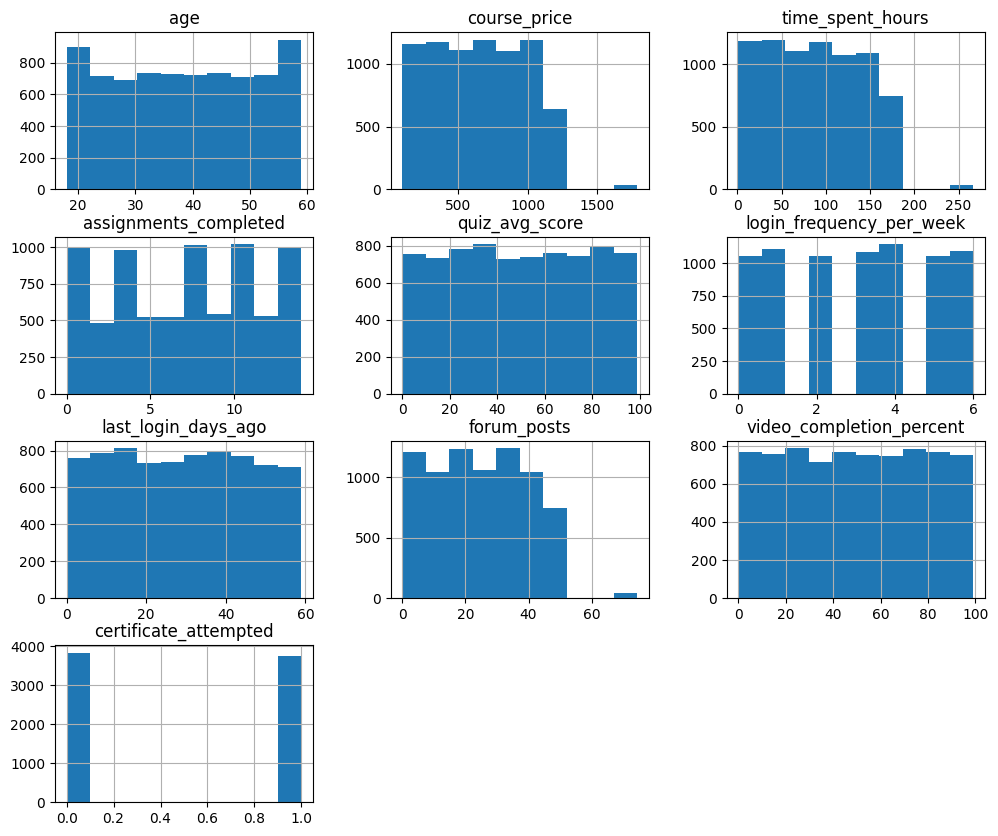

In [ ]:
df[num_cols].hist(figsize=(12,10))
plt.show()

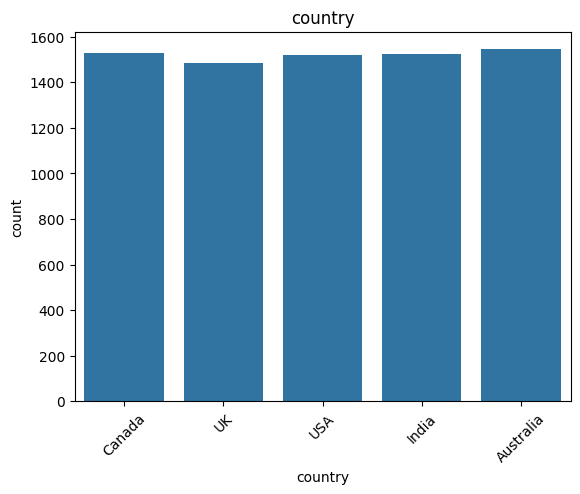

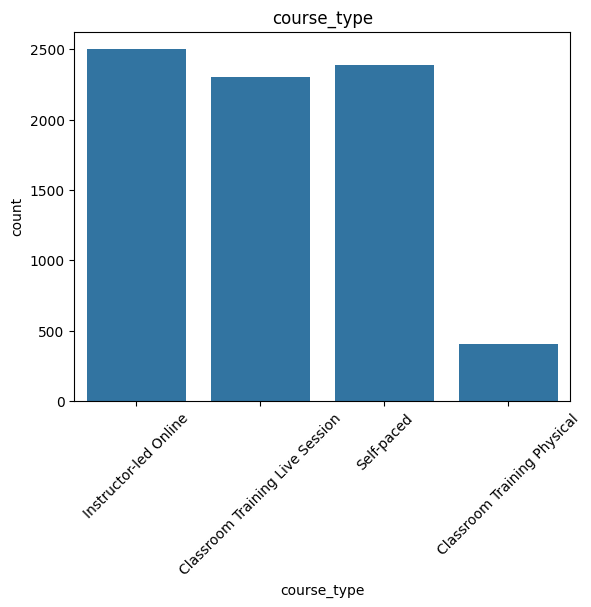

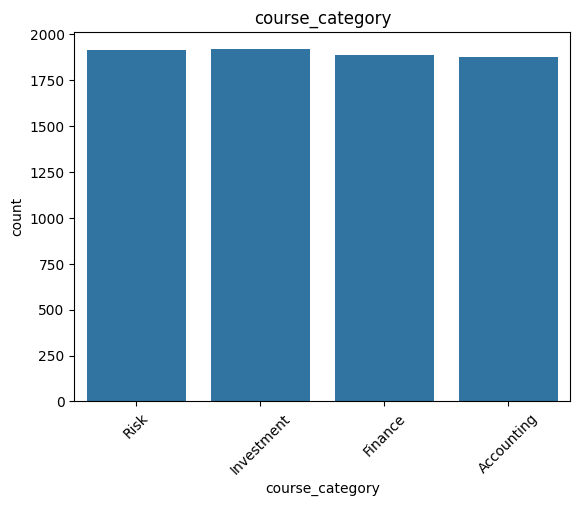

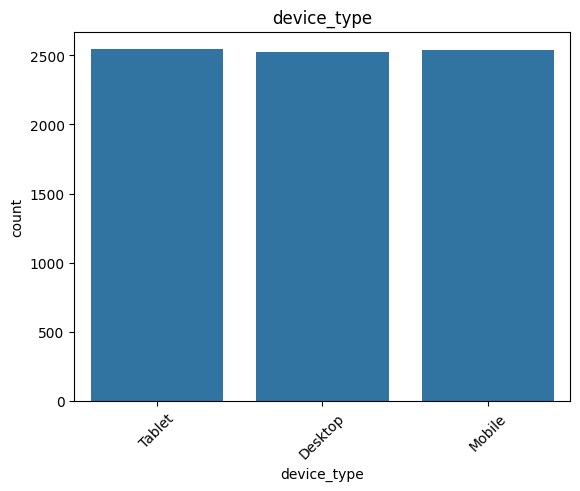

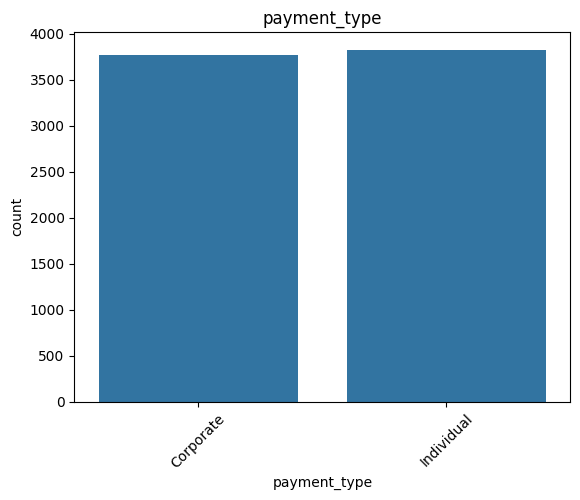

In [ ]:
cat_cols = ['country','course_type','course_category','device_type','payment_type']

for col in cat_cols:
    sns.countplot(x=col, data=df)
    plt.xticks(rotation=45)
    plt.title(col)
    plt.show()

Numerical features show varied distributions, indicating diverse learner engagement and performance.
Categorical features show balanced distribution across countries, course types, and device usage.

BIvariate Analysis

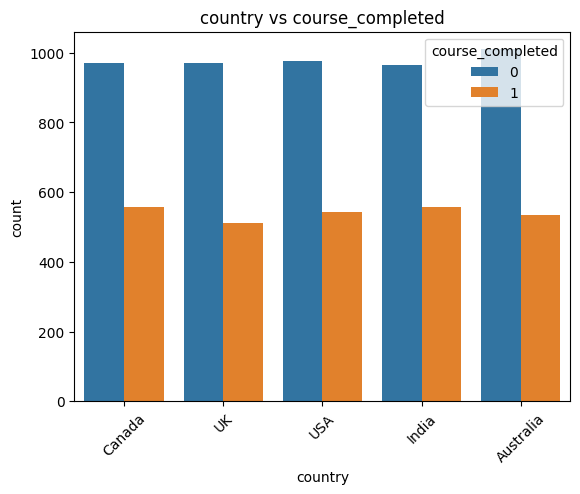

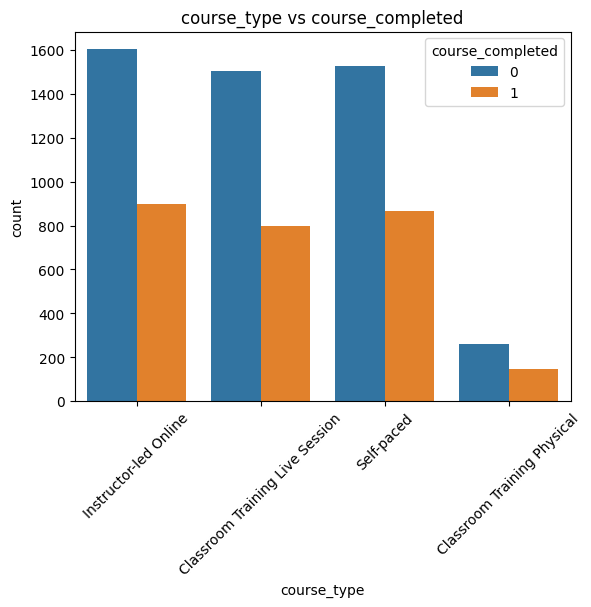

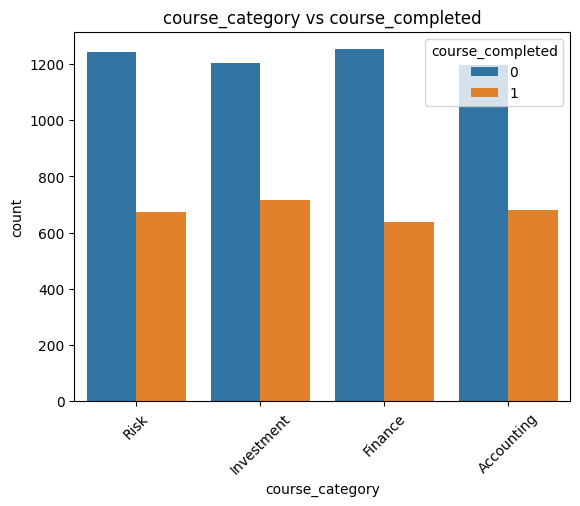

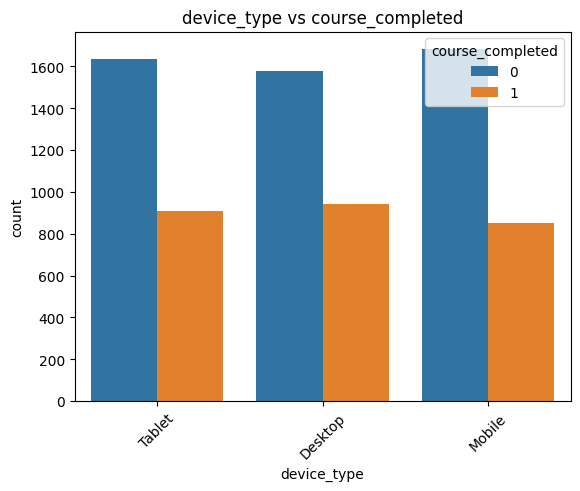

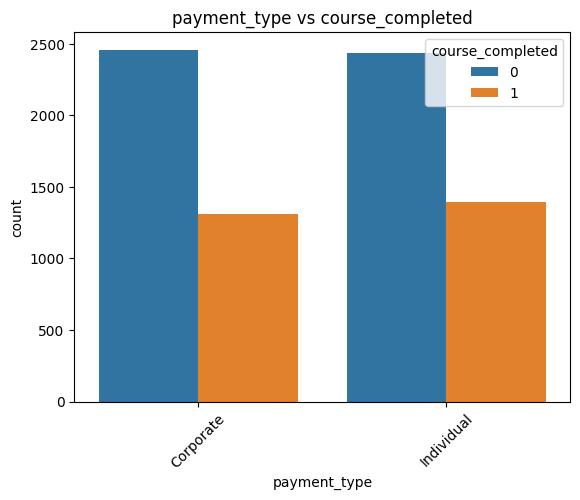

In [ ]:
for col in cat_cols:
    sns.countplot(x=col, hue='course_completed', data=df)
    plt.xticks(rotation=45)
    plt.title(f"{col} vs course_completed")
    plt.show()

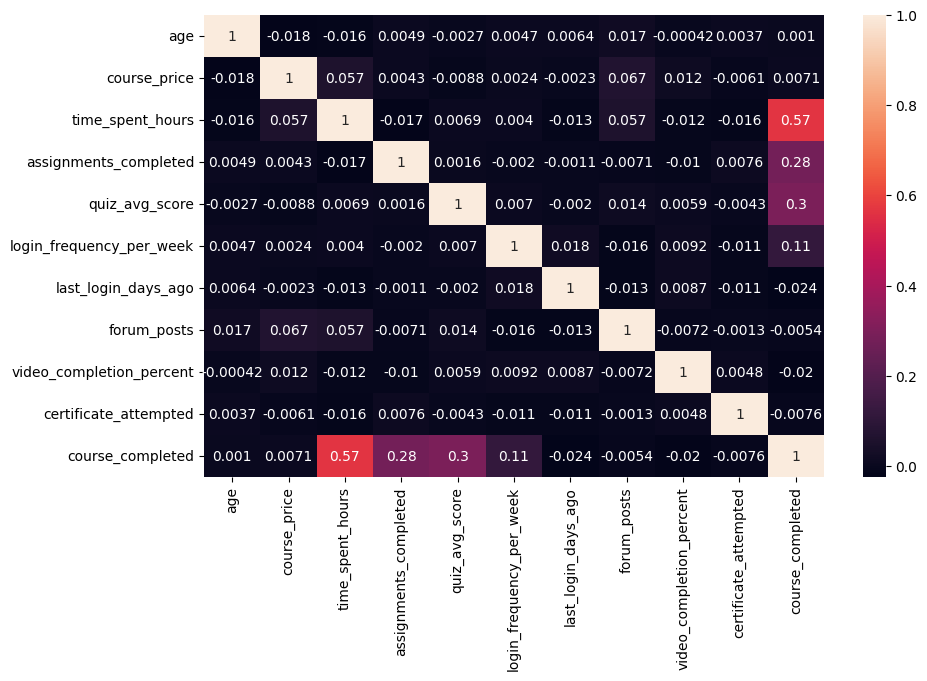

In [ ]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True)
plt.show()

positive correlation is observed between course completion and features such as time spent, quiz scores, and assignment completion. Other features show weak to moderate relationships.

Exploratory Data Analysis reveals that learner engagement and performance metrics are the key drivers of course completion. Features such as time spent, quiz scores, and assignments completed show strong relationships with the target variable, while demographic and course-related attributes have moderate influence.

Encoding

In [ ]:
cat_cols = df.select_dtypes(include=['object']).columns
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

One-hot encoding was used for categorical variables as they are nominal in nature and do not have any inherent order. Label encoding was avoided to prevent introducing misleading ordinal relationships.

In [ ]:
df_encoded.head()


,age,course_price,time_spent_hours,assignments_completed,quiz_avg_score,login_frequency_per_week,last_login_days_ago,forum_posts,video_completion_percent,certificate_attempted,...,country_USA,course_type_Classroom Training Physical,course_type_Instructor-led Online,course_type_Self-paced,course_category_Finance,course_category_Investment,course_category_Risk,device_type_Mobile,device_type_Tablet,payment_type_Individual
0,32,1195.0,21.0,6,82,6,10,23.0,99,1,...,False,False,True,False,False,False,True,False,True,False
1,19,905.0,130.0,11,20,0,21,43.0,88,0,...,False,False,False,False,False,True,False,False,False,True
2,59,799.0,15.0,13,61,6,50,43.0,54,1,...,False,False,False,True,False,True,False,False,False,False
3,54,746.0,21.0,8,38,1,59,13.0,8,1,...,True,False,False,False,False,False,True,True,False,True
4,24,608.0,8.0,14,34,5,35,49.0,3,1,...,False,False,False,True,False,True,False,True,False,False


In [ ]:
df_encoded.shape

(7600, 24)

In [ ]:
df = df_encoded

In [ ]:
df

,age,course_price,time_spent_hours,assignments_completed,quiz_avg_score,login_frequency_per_week,last_login_days_ago,forum_posts,video_completion_percent,certificate_attempted,...,country_USA,course_type_Classroom Training Physical,course_type_Instructor-led Online,course_type_Self-paced,course_category_Finance,course_category_Investment,course_category_Risk,device_type_Mobile,device_type_Tablet,payment_type_Individual
0,32,1195.0,21.0,6,82,6,10,23.0,99,1,...,False,False,True,False,False,False,True,False,True,False
1,19,905.0,130.0,11,20,0,21,43.0,88,0,...,False,False,False,False,False,True,False,False,False,True
2,59,799.0,15.0,13,61,6,50,43.0,54,1,...,False,False,False,True,False,True,False,False,False,False
3,54,746.0,21.0,8,38,1,59,13.0,8,1,...,True,False,False,False,False,False,True,True,False,True
4,24,608.0,8.0,14,34,5,35,49.0,3,1,...,False,False,False,True,False,True,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,35,1160.0,90.0,0,0,2,21,18.0,76,0,...,False,False,False,True,False,True,False,True,False,False
7996,52,183.0,26.0,13,34,4,13,28.0,57,0,...,False,False,False,True,True,False,False,False,False,True
7997,35,947.0,130.0,9,97,1,28,1.0,15,1,...,False,False,True,False,False,False,True,False,False,False
7998,53,1001.0,105.0,4,94,0,1,34.0,27,0,...,False,False,True,False,False,False,False,True,False,True


Categorical features were encoded using one-hot encoding to convert them into numerical format suitable for machine learning models. To avoid multicollinearity, one category from each feature was dropped.

Model Builing

In [ ]:
#train test split
X = df.drop('course_completed', axis=1)
y = df['course_completed']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2
)

The dataset is split into training and testing sets to evaluate model performance on unseen data.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

PCA

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)

X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)

In [ ]:
X_train

array([[-0.88411825, -0.9693905 , -1.25896724, ..., -0.35591134,
        -0.03310372,  0.40789752],
       [-0.54244973, -1.43916652,  0.93466309, ..., -0.55998828,
         0.0986196 ,  0.45182541],
       [-0.88534661,  0.57586931, -1.36947596, ..., -0.50490212,
        -0.08278131, -1.08614033],
       ...,
       [ 1.15788366,  0.89712904, -1.19164462, ...,  0.57391972,
        -1.71956754, -0.97986709],
       [-0.91635125,  0.16643578,  2.11796986, ...,  0.40428304,
         0.12263163,  0.48540646],
       [-0.53460627,  0.33770938, -0.3414409 , ..., -0.88620492,
         0.71749522, -0.95603527]])

Train Models

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Models
lr = LogisticRegression(max_iter=1000)
dt = DecisionTreeClassifier()
rf = RandomForestClassifier()

# Train
lr.fit(X_train, y_train)
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)

RandomForestClassifier()

Predictions

In [ ]:
y_pred_lr = lr.predict(X_test)
y_pred_dt = dt.predict(X_test)
y_pred_rf = rf.predict(X_test)

In [ ]:
#evaluation function
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix

def evaluate(model_name, y_test, y_pred):
    print(f"----- {model_name} -----")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    print("\n")

In [ ]:
#compare models
evaluate("Logistic Regression", y_test, y_pred_lr)
evaluate("Decision Tree", y_test, y_pred_dt)
evaluate("Random Forest", y_test, y_pred_rf)

----- Logistic Regression -----
Accuracy: 0.8644736842105263
              precision    recall  f1-score   support

           0       0.89      0.90      0.89       972
           1       0.81      0.81      0.81       548

    accuracy                           0.86      1520
   macro avg       0.85      0.85      0.85      1520
weighted avg       0.86      0.86      0.86      1520



----- Decision Tree -----
Accuracy: 0.75
              precision    recall  f1-score   support

           0       0.80      0.81      0.81       972
           1       0.66      0.64      0.65       548

    accuracy                           0.75      1520
   macro avg       0.73      0.73      0.73      1520
weighted avg       0.75      0.75      0.75      1520



----- Random Forest -----
Accuracy: 0.8355263157894737
              precision    recall  f1-score   support

           0       0.84      0.91      0.88       972
           1       0.82      0.70      0.75       548

    accuracy         

In [ ]:
from sklearn.metrics import precision_score, recall_score

# Logistic Regression
print("LR Precision:", precision_score(y_test, y_pred_lr))
print("LR Recall:", recall_score(y_test, y_pred_lr))

# Decision Tree
print("DT Precision:", precision_score(y_test, y_pred_dt))
print("DT Recall:", recall_score(y_test, y_pred_dt))

# Random Forest
print("RF Precision:", precision_score(y_test, y_pred_rf))
print("RF Recall:", recall_score(y_test, y_pred_rf))

LR Precision: 0.8131868131868132
LR Recall: 0.8102189781021898
DT Precision: 0.6567164179104478
DT Recall: 0.6423357664233577
RF Precision: 0.815677966101695
RF Recall: 0.7025547445255474


Logistic Regression is selected as the final model as it provides a balanced trade-off between precision and recall, ensuring that both completed and at-risk learners are identified effectively. This balance is crucial for making reliable decisions in a learning platform, where both identifying successful learners and detecting potential dropouts are important.

In [ ]:
#confusion matrix
cm = confusion_matrix(y_test, y_pred_lr)
print(cm)

[[870 102]
 [104 444]]


Visualization

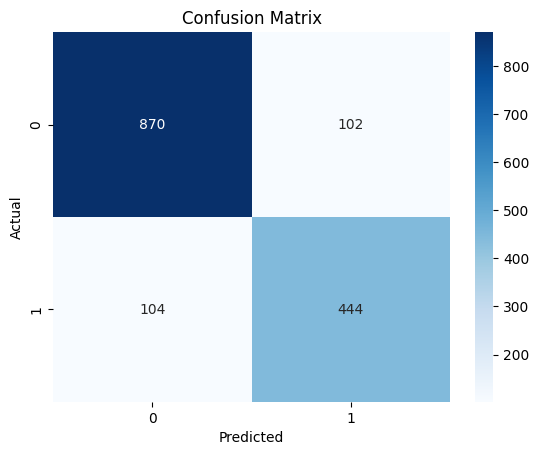

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Predict new data

In [ ]:
new_data = pd.DataFrame([{
    'age': 30,
    'course_price': 500,
    'time_spent_hours': 40,
    'assignments_completed': 6,
    'quiz_avg_score': 75,
    'login_frequency_per_week': 4,
    'forum_posts': 10,
    'last_login_days_ago': 2,
    'video_completion_percent': 80,
    'certificate_attempted': 1,
    'country': 'India',
    'course_type': 'Self-paced',
    'course_category': 'Finance',
    'device_type': 'Mobile',
    'payment_type': 'Individual'
}])

In [ ]:
#apply same encoding
# One-hot encode
new_data = pd.get_dummies(new_data)


In [ ]:
new_data = new_data.reindex(columns=X.columns, fill_value=0)

In [ ]:
new_data = scaler.transform(new_data)

In [ ]:
#apply PCA for new data
new_data_pca = pca.transform(new_data)
prediction = lr.predict(new_data_pca)


In [ ]:
print(prediction)

[0]


In [ ]:
#another new data of completed status i.e. 1
new_data = pd.DataFrame([{
    'age': 26,
    'country': 'UK',
    'course_type': 'Self-paced',
    'course_category': 'Finance',
    'course_price': 915,
    'time_spent_hours': 131,
    'login_frequency_per_week': 3,
    'forum_posts': 23,
    'assignments_completed': 5,
    'device_type': 'Mobile',
    'last_login_days_ago': 23,
    'video_completion_percent': 10,
    'quiz_avg_score': 71,
    'certificate_attempted': 1,
    'payment_type': 'Corporate'
}])

new_data = pd.get_dummies(new_data)
new_data = new_data.reindex(columns=X.columns, fill_value=0)
new_data = scaler.transform(new_data)
new_data_pca = pca.transform(new_data)
prediction = lr.predict(new_data_pca)
print(prediction)

[1]


The model predicted that the learner is unlikely to complete the course based on their engagement and performance metrics.

Based on the input features such as time spent on the course, quiz performance, assignment completion, and engagement levels, the model predicts that the learner is unlikely to complete the course (class 0). The probability score further indicates a high likelihood of non-completion, suggesting that the learner may be at risk and could benefit from timely intervention.

In [ ]:
print(lr.classes_)
lr.predict_proba(new_data_pca)

[0 1]


array([[0.91616349, 0.08383651]])

The model predicts that the learner is unlikely to complete the course, with an 91% probability of non-completion and only a 9% probability of completion. This indicates a high risk of dropout.

The high probability of non-completion suggests that this learner is at risk and may require proactive intervention such as reminders, additional support, or personalized engagement strategies to improve completion chances.